# 🧬 Regulatory DNA Modeling & Interpretable AI

**Sequence-based modeling of regulatory DNA using convolutional neural networks, interpretable k-mer models, rigorous validation, and in silico perturbation**

This project evaluates whether regulatory DNA sequences contain reproducible predictive signal associated with a binary transcriptional response.

The workflow combines deep learning, interpretable sequence models, leakage-aware dataset design, nested cross-validation, permutation testing, independent test evaluation, and controlled in silico perturbations.

**Salomé Gastaldi, PhD**  
Computational Biology | Bioinformatics | AI for Life Sciences

## Project Scope

This notebook serves as a **technical case-study interface** for a larger modular analysis pipeline.

The main computational workflow was implemented through reusable Python scripts and components available in the `scripts/` and `src/` directories. The notebook focuses on summarizing the modeling strategy, evaluation results, interpretability analyses, and methodological conclusions.

The project was designed with emphasis on:

- reproducible sequence-based modeling;
- strict separation between development and independent test data;
- class-imbalance-aware evaluation;
- comparison between deep and interpretable models;
- model selection without test-set leakage;
- statistical validation through permutation testing;
- post hoc sequence interpretation;
- controlled in silico perturbation experiments.

## Confidentiality and Data Availability

The original biological dataset and selected external regulatory references are subject to **confidentiality restrictions** and are not distributed in this public repository.

The public version intentionally excludes:

- original regulatory DNA sequences;
- biological identifiers;
- source labels and internal annotations;
- confidential external regulatory references;
- non-public intermediate analysis files;
- any information that could allow reconstruction of the original industrial dataset.

Only sanitized code, aggregated model metrics, public-safe summaries, and non-identifying visualizations are included.

The purpose of this repository is to demonstrate the **computational methodology, modeling strategy, validation framework, and interpretability workflow** without exposing proprietary biological information.


## Experimental Design and Modeling Workflow

The study was designed as a **sequence-only feasibility analysis** to determine whether promoter sequences contain reproducible predictive information associated with a binary transcriptional response.

The workflow was organized into successive stages:

1. **Dataset construction and quality control**  
   Sequence preparation, class definition, and sequence-similarity auditing to reduce the risk of data leakage across dataset partitions.

2. **CNN baseline model**  
   Training of a convolutional neural network directly on one-hot encoded promoter sequences, followed by model diagnostics, class-weight evaluation, decision-threshold analysis, and final evaluation.

3. **Interpretable k-mer model**  
   Representation of promoter sequences using k-mer frequencies and training of a regularized logistic regression classifier. Model selection was performed using nested cross-validation.

4. **Permutation testing**  
   Assessment of whether the observed predictive performance could arise from chance associations by comparison with a null distribution generated through label permutation.

5. **Feature interpretation**  
   Analysis of k-mers positively and negatively associated with model predictions to characterize the sequence patterns contributing to the predictive signal.

6. **Independent regulatory validation**  
   Post hoc comparison of learned sequence patterns with independent regulatory evidence. The specific resources used at this stage are not distributed due to confidentiality restrictions.

7. **In silico perturbation**  
   Proof-of-concept experiments evaluating whether controlled modifications of selected sequence patterns produce directionally consistent changes in model predictions.

8. **Independent test evaluation**  
   Final assessment of generalization on sequences that were not used during model training or selection.

This design separates **predictive performance, statistical robustness, interpretability, and generalization**, avoiding conclusions based on a single metric or modeling strategy.

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

# La notebook se encuentra en notebooks/, por lo que la raíz
# del repositorio corresponde al directorio padre.
REPO_ROOT = Path.cwd().parent

RESULTS_DIR = REPO_ROOT / "results"
RESULTS = RESULTS_DIR

assert RESULTS_DIR.exists(), "No se encontró el directorio results/."

print("Estructura principal del repositorio verificada correctamente.")

Estructura principal del repositorio verificada correctamente.


In [2]:
print("RESULTS     :", RESULTS)
print("RESULTS_DIR :", RESULTS_DIR)

print()
print("Results exists     :", RESULTS.exists())
print("Results dir exists :", RESULTS_DIR.exists())

print()
print("CNN JSON exists    :", (
    RESULTS_DIR
    / "metrics"
    / "pos_weight_ablation_summary.json"
).exists())

RESULTS     : /home/salo/Documentos/ai-for-drug-discovery/09-Regulatory-DNA-Interpretable-AI/results
RESULTS_DIR : /home/salo/Documentos/ai-for-drug-discovery/09-Regulatory-DNA-Interpretable-AI/results

Results exists     : True
Results dir exists : True

CNN JSON exists    : True


In [3]:
cnn_selection_path = RESULTS_DIR / "metrics" / "pos_weight_ablation_summary.json"
cnn_test_path = RESULTS_DIR / "metrics" / "cnn_baseline_test_summary.json"

with open(cnn_selection_path, "r", encoding="utf-8") as f:
    cnn_selection = json.load(f)

with open(cnn_test_path, "r", encoding="utf-8") as f:
    cnn_test = json.load(f)

cnn_test_metrics = cnn_test["metrics"]

cnn_summary_df = pd.DataFrame(
    {
        "Etapa": ["Validación", "Test independiente"],
        "AUPRC": [
            cnn_selection["best_configuration"]["best_validation_auprc"],
            cnn_test_metrics["auprc"],
        ],
        "AUROC": [
            cnn_selection["best_configuration"]["best_validation_auroc"],
            cnn_test_metrics["auroc"],
        ],
    }
)

print("Resumen del desempeño de la CNN seleccionada")
display(cnn_summary_df.round(3))

Resumen del desempeño de la CNN seleccionada


,Etapa,AUPRC,AUROC
0,Validación,0.236,0.610
1,Test independiente,0.093,0.465


Curva Precision–Recall — CNN


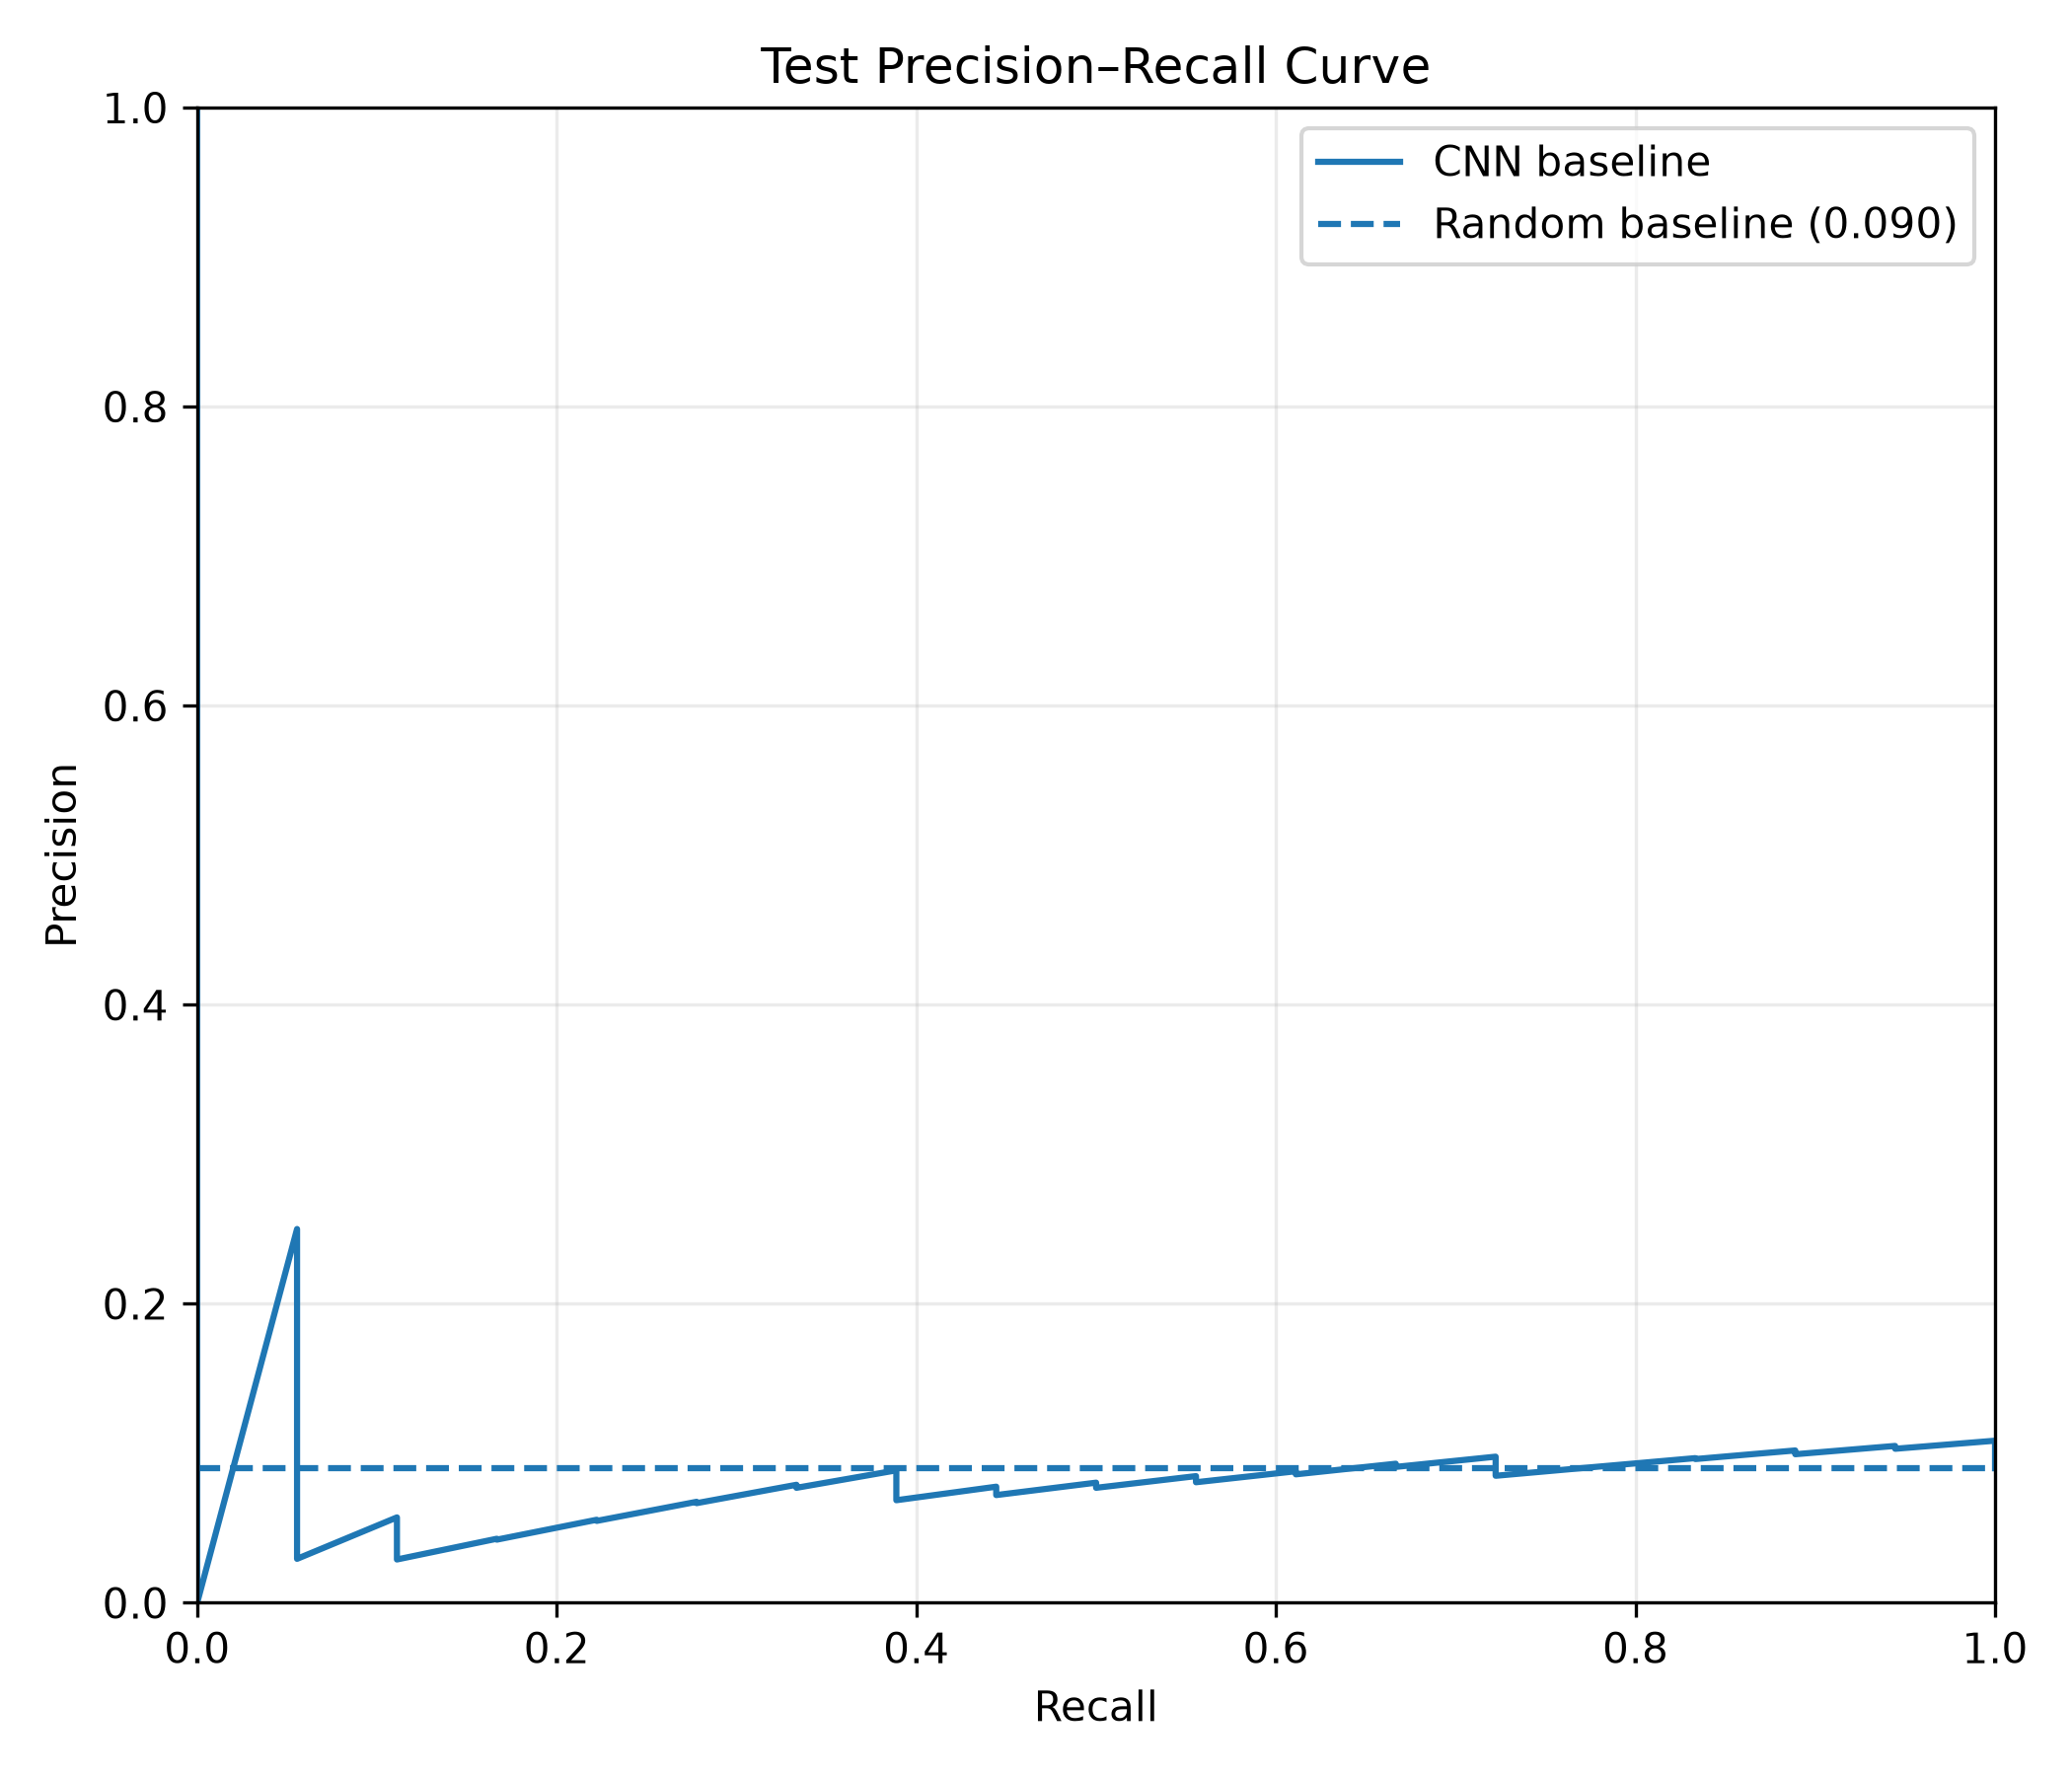

Curva ROC — CNN


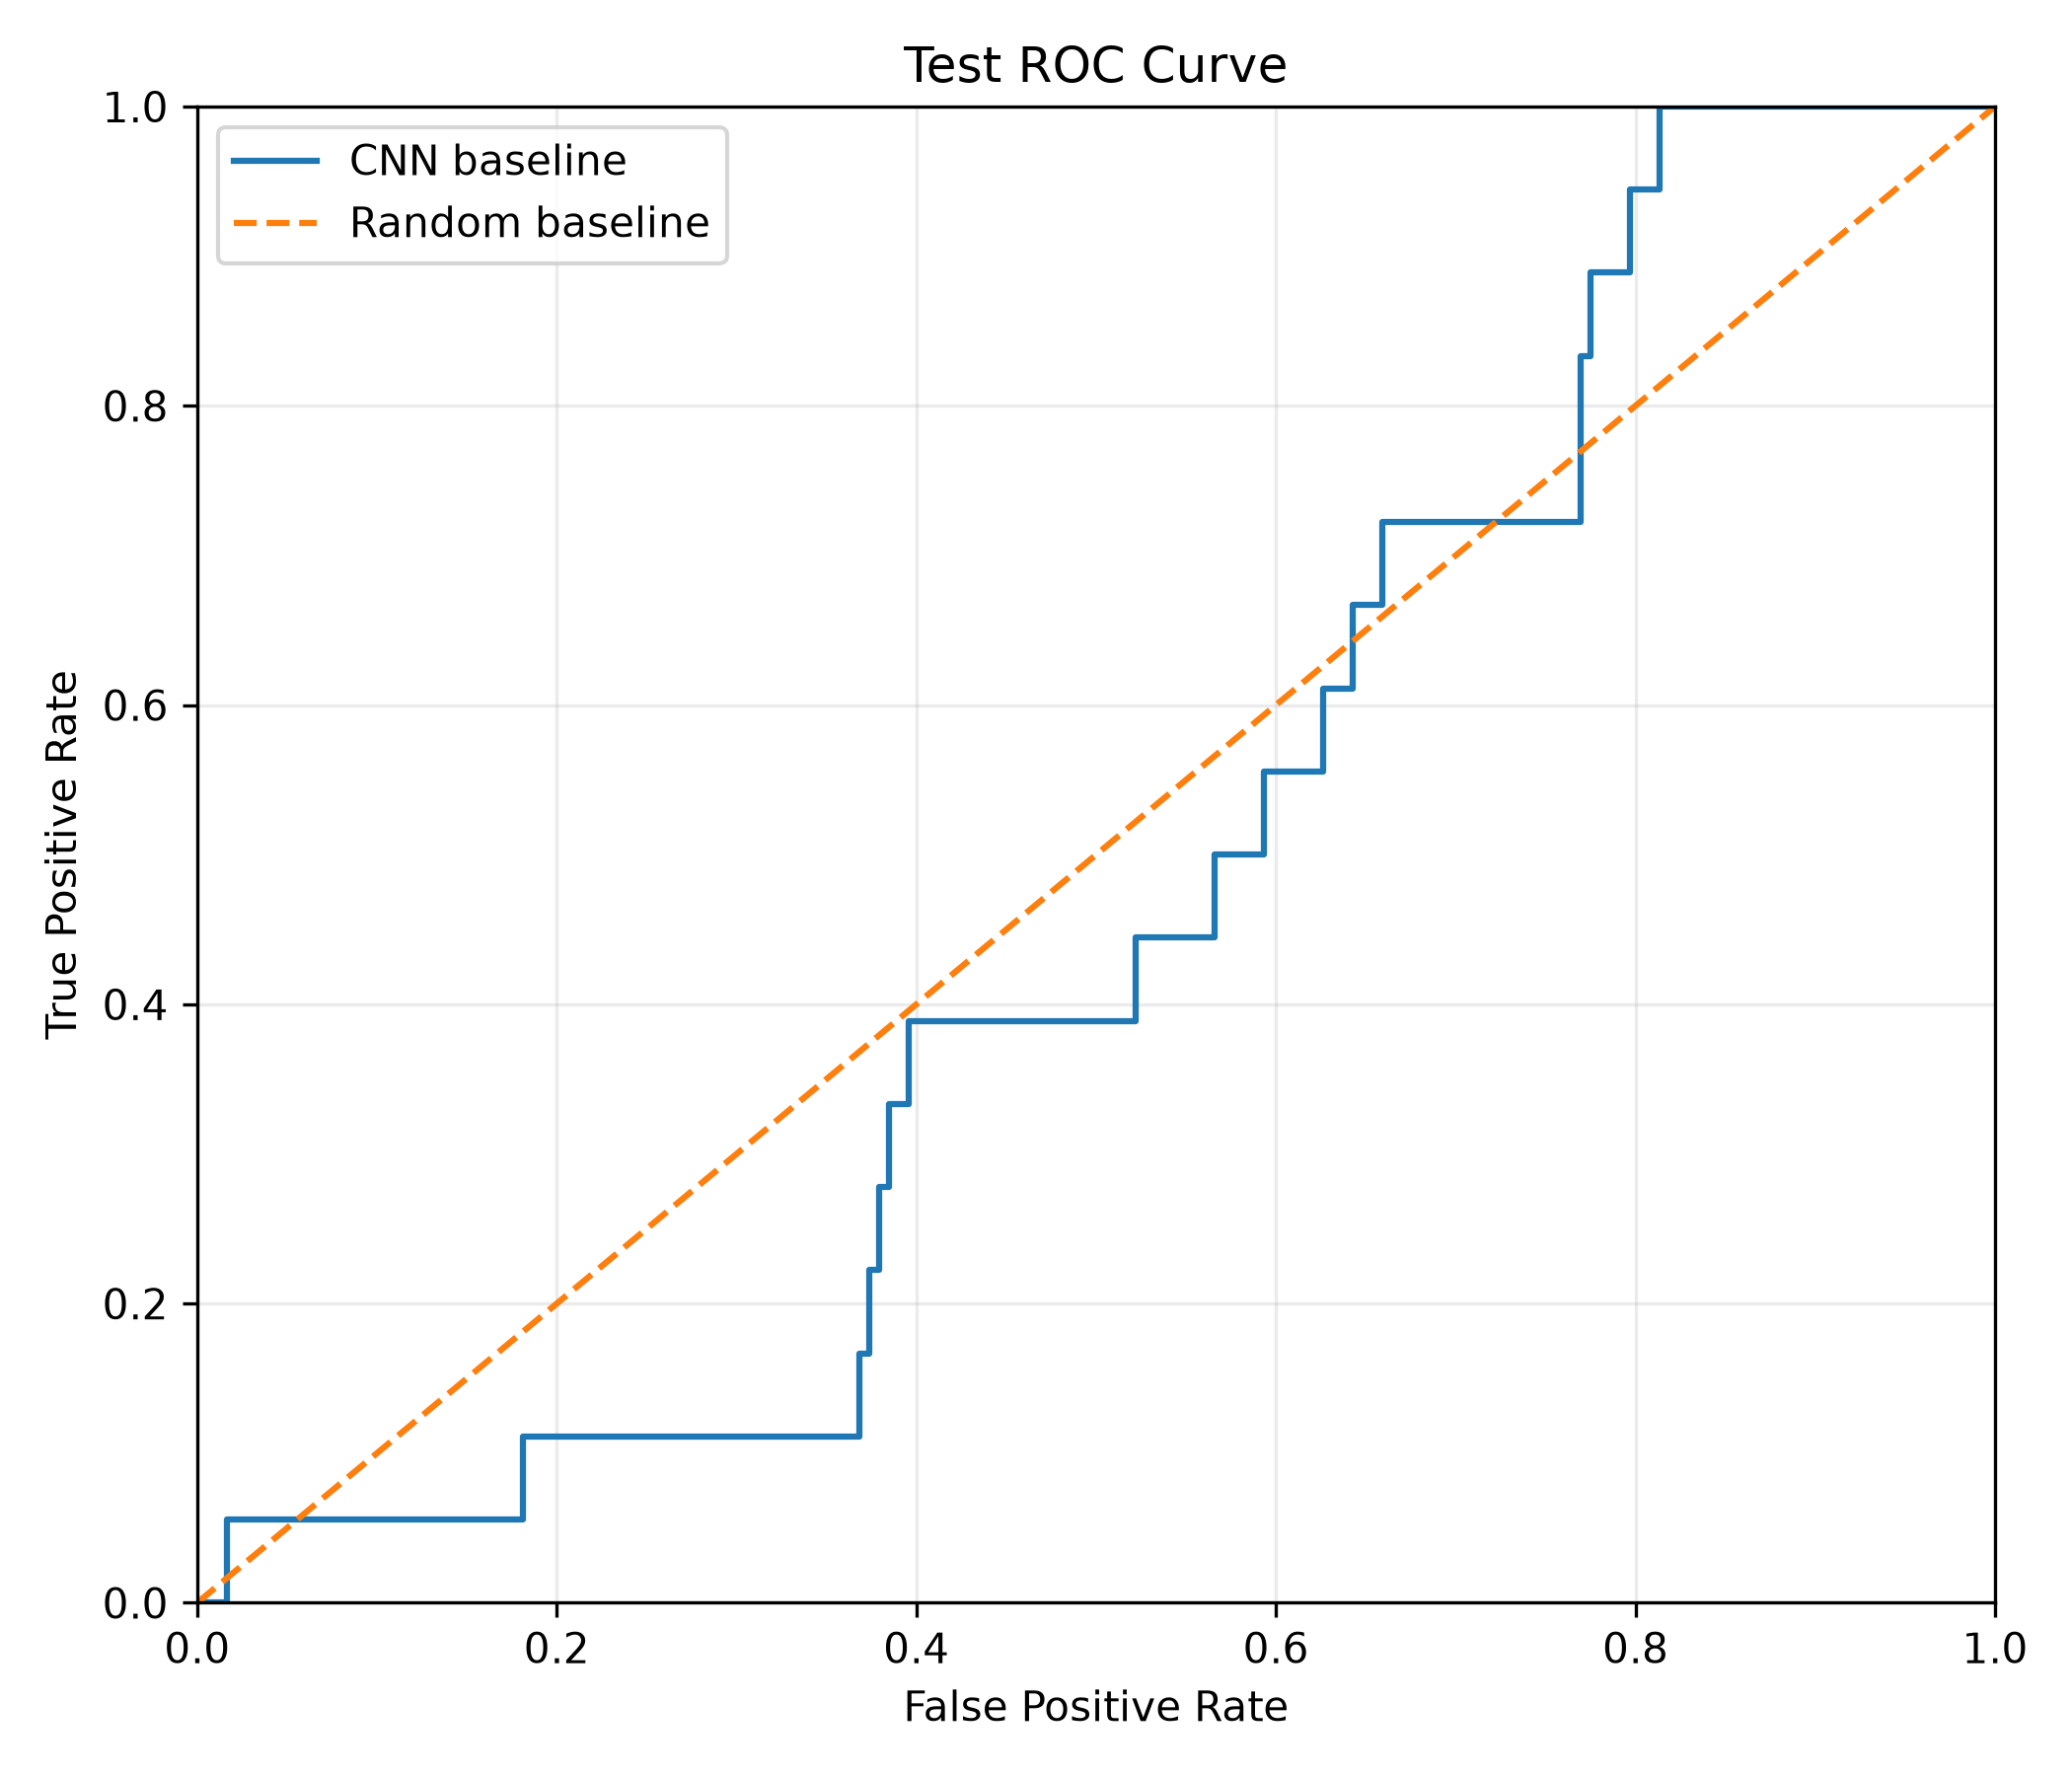

Matriz de confusión — CNN


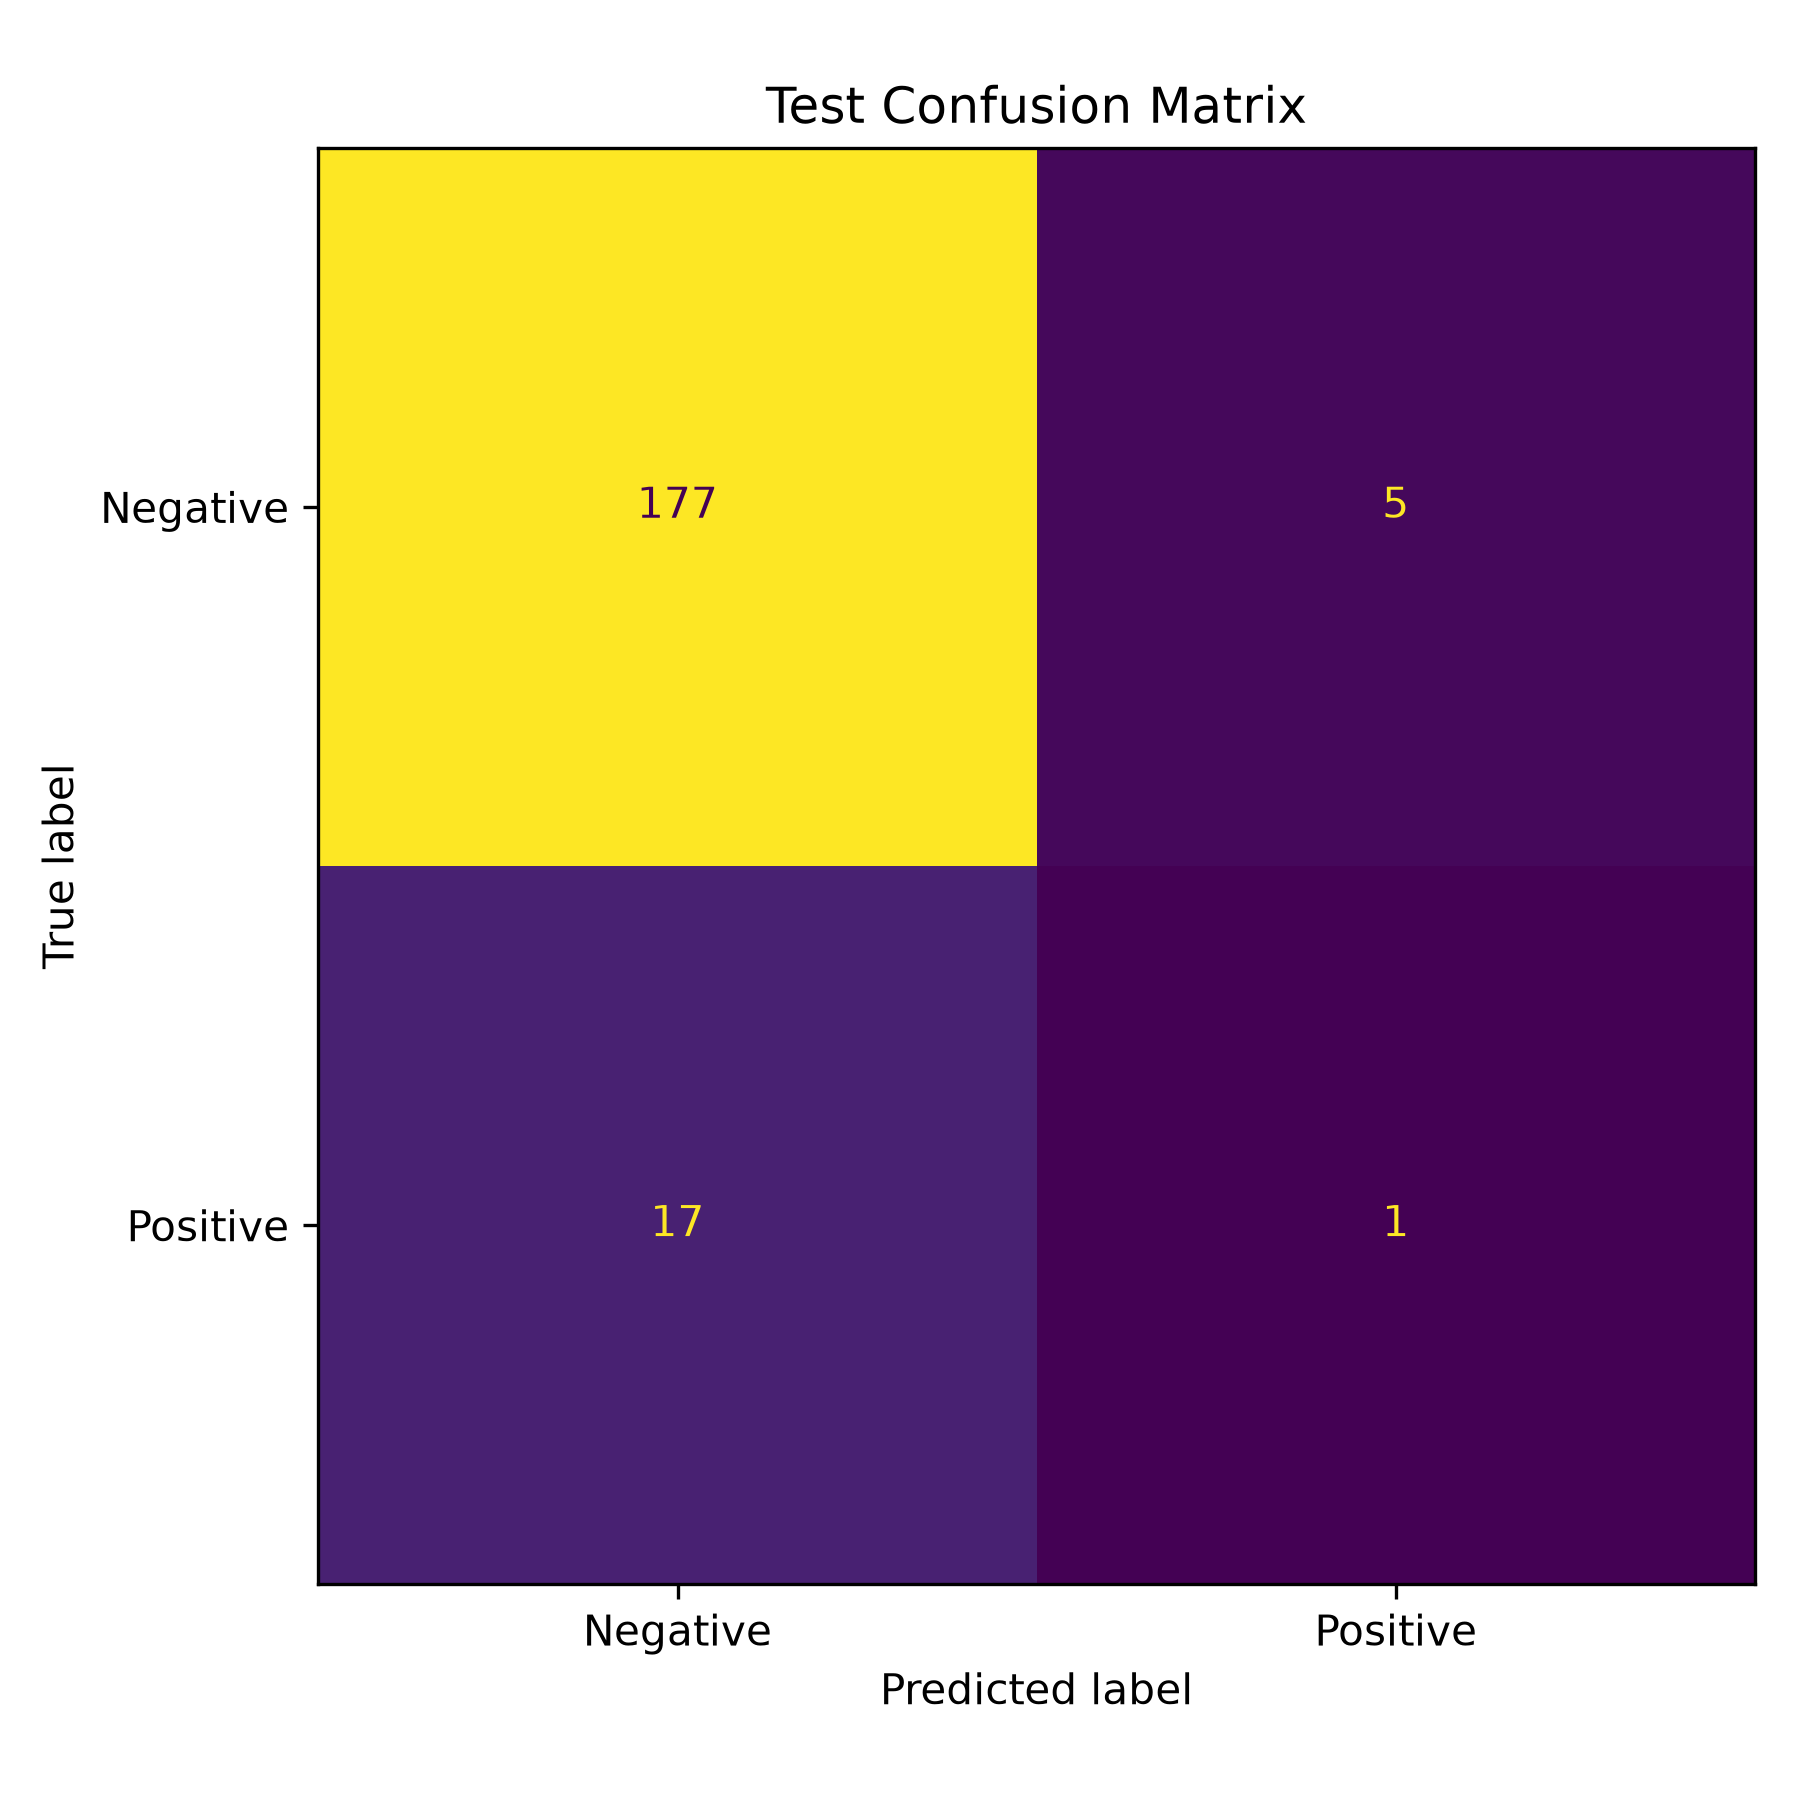

In [4]:
from IPython.display import Image, display

cnn_figures = [
    RESULTS_DIR / "figures" / "precision_recall_curve_test.png",
    RESULTS_DIR / "figures" / "roc_curve_test.png",
    RESULTS_DIR / "figures" / "confusion_matrix_test.png",
]

titles = [
    "Curva Precision–Recall — CNN",
    "Curva ROC — CNN",
    "Matriz de confusión — CNN",
]

for title, path in zip(titles, cnn_figures):
    print(title)
    display(Image(filename=str(path)))

### CNN Performance and Generalization

The CNN showed moderate discriminative ability during validation, reaching an AUPRC of 0.236 and an AUROC of 0.610. However, this performance did not persist on the independent test set, where the selected model achieved an AUPRC of 0.093 and an AUROC of 0.465.

The decrease from validation to independent testing indicates limited generalization to sequences not used during model development. The CNN therefore did not provide sufficient evidence to be considered a robust classifier for this dataset.

This result motivated the evaluation of a complementary and more interpretable strategy based on k-mer frequencies and logistic regression, with particular emphasis on cross-validation, permutation controls, and interpretation of predictive sequence features.

## Interpretable k-mer Logistic Regression

Given the limited generalization of the CNN on the independent test set, a more constrained and interpretable representation based on k-mer frequencies was evaluated.

Each promoter sequence was represented using normalized frequencies of short sequence patterns, which were used as input features for a regularized logistic regression classifier.

Model selection was performed using **nested cross-validation** to separate hyperparameter optimization from performance estimation and reduce the risk of optimistic bias in a limited-size dataset.

This framework enabled simultaneous evaluation of:

- predictive performance;
- performance stability across folds;
- statistical evidence for the predictive signal through permutation testing;
- individual contributions of sequence patterns through model coefficients.

In [5]:
kmer_cv_path = (
    RESULTS_DIR
    / "metrics"
    / "kmer_logistic_nested_cv_summary.json"
)

with open(kmer_cv_path, "r", encoding="utf-8") as f:
    kmer_cv = json.load(f)

outer_metrics = kmer_cv["outer_fold_metric_distribution"]

kmer_cv_summary = pd.DataFrame(
    {
        "Métrica": ["AUPRC", "AUROC"],
        "Media": [
            outer_metrics["auprc"]["mean"],
            outer_metrics["auroc"]["mean"],
        ],
        "Desvío estándar": [
            outer_metrics["auprc"]["std"],
            outer_metrics["auroc"]["std"],
        ],
        "Mínimo": [
            outer_metrics["auprc"]["min"],
            outer_metrics["auroc"]["min"],
        ],
        "Máximo": [
            outer_metrics["auprc"]["max"],
            outer_metrics["auroc"]["max"],
        ],
    }
)

print("Validación cruzada anidada — regresión logística basada en k-mers")
display(kmer_cv_summary.round(3))

Validación cruzada anidada — regresión logística basada en k-mers


,Métrica,Media,Desvío estándar,Mínimo,Máximo
0,AUPRC,0.194,0.043,0.155,0.272
1,AUROC,0.651,0.041,0.572,0.685


In [6]:
permutation_path = (
    RESULTS_DIR
    / "metrics"
    / "kmer_logistic_permutation_test_summary.json"
)

with open(permutation_path, "r", encoding="utf-8") as f:
    permutation = json.load(f)

observed = permutation["observed"]
null_dist = permutation["null_distribution"]
significance = permutation["significance"]

permutation_summary = pd.DataFrame(
    {
        "Métrica": ["AUPRC", "AUROC"],
        "Observado": [
            observed["auprc"],
            observed["auroc"],
        ],
        "Media nula": [
            null_dist["auprc_mean"],
            null_dist["auroc_mean"],
        ],
        "p empírico": [
            significance["auprc_empirical_p_value"],
            significance["auroc_empirical_p_value"],
        ],
    }
)

print("Prueba de permutación — modelo basado en k-mers")
display(permutation_summary.round(3))

Prueba de permutación — modelo basado en k-mers


,Métrica,Observado,Media nula,p empírico
0,AUPRC,0.197,0.093,0.005
1,AUROC,0.656,0.490,0.005


### Permutation Test

The fixed k-mer model configuration achieved an observed AUPRC of 0.197 and an AUROC of 0.656. Across 200 label permutations, none of the null-distribution values matched or exceeded the observed performance, resulting in an empirical *p*-value of approximately 0.005 for both metrics.

These results indicate that the predictive signal detected by the model is unlikely to be explained exclusively by chance under the evaluated permutation scheme.

The permutation test should be interpreted as a statistical control conditional on a previously fixed model configuration. It does not reproduce the complete hyperparameter-selection procedure within each permutation and therefore does not replace the nested cross-validation framework used during model development.

In [7]:
kmer_test_path = (
    RESULTS_DIR
    / "metrics"
    / "kmer_logistic_test_summary.json"
)

with open(kmer_test_path, "r", encoding="utf-8") as f:
    kmer_test = json.load(f)

metrics = kmer_test["metrics"]
test_data = kmer_test["test_data"]

kmer_test_summary = pd.DataFrame(
    {
        "Métrica": [
            "AUPRC",
            "AUROC",
            "Baseline aleatorio AUPRC",
            "MCC (umbral 0.5)",
            "F1 (umbral 0.5)",
            "Balanced Accuracy (umbral 0.5)",
        ],
        "Valor": [
            metrics["auprc"],
            metrics["auroc"],
            test_data["random_auprc_baseline"],
            metrics["mcc"],
            metrics["f1"],
            metrics["balanced_accuracy"],
        ],
    }
)

print("Evaluación final — modelo de k-mers sobre Test independiente")
display(kmer_test_summary.round(3))

Evaluación final — modelo de k-mers sobre Test independiente


,Métrica,Valor
0,AUPRC,0.184
1,AUROC,0.612
2,Baseline aleatorio AUPRC,0.090
3,MCC (umbral 0.5),0.000
4,F1 (umbral 0.5),0.000
5,Balanced Accuracy (umbral 0.5),0.500


### Independent Test Evaluation

The final k-mer model was frozen before accessing the test set and evaluated only once, with no feature selection, hyperparameter tuning, or threshold optimization performed on these data.

On the independent test set, the model achieved an AUPRC of 0.184 compared with a random baseline of 0.090, together with an AUROC of 0.612. These results indicate that the model retained ranking and discriminative ability on data not used during model development.

However, using the fixed classification threshold of 0.5, the model did not predict any samples as positive, resulting in MCC and F1 values of 0 and a balanced accuracy of 0.5. Thus, the ranking performance reflected by AUPRC and AUROC did not directly translate into useful binary classification at this decision threshold.

This distinction highlights the importance of separating threshold-independent discrimination metrics from threshold-dependent classification metrics, particularly in imbalanced prediction problems. The threshold was not readjusted using the test set, preserving its independence as the final evaluation dataset.

In [8]:
cnn_test_metrics = cnn_test["metrics"]
kmer_test_metrics = kmer_test["metrics"]

model_comparison = pd.DataFrame(
    {
        "Modelo": [
            "CNN",
            "Regresión logística (5-mers)",
        ],
        "AUPRC": [
            cnn_test_metrics["auprc"],
            kmer_test_metrics["auprc"],
        ],
        "AUROC": [
            cnn_test_metrics["auroc"],
            kmer_test_metrics["auroc"],
        ],
    }
)

print("Comparación de modelos sobre Test independiente")
display(model_comparison.round(3))

Comparación de modelos sobre Test independiente


,Modelo,AUPRC,AUROC
0,CNN,0.093,0.465
1,Regresión logística (5-mers),0.184,0.612


### Model Comparison on the Independent Test Set

The final comparison revealed clearly different generalization behavior between the two modeling strategies. The CNN achieved an AUPRC of 0.093 and an AUROC of 0.465, whereas the 5-mer logistic regression model achieved an AUPRC of 0.184 and an AUROC of 0.612 on the same independent test set.

In this experiment, the k-mer model generalized better than the CNN. Its AUPRC remained above the random baseline defined by the positive-class prevalence in the test set (0.090), whereas CNN performance was close to this baseline.

These results suggest that, given the size and characteristics of the available dataset, an explicit representation of local sequence composition combined with a regularized linear model was more effective than the evaluated convolutional architecture.

This comparison does not imply that k-mer models are intrinsically superior to CNNs for regulatory sequence analysis. The conclusion is restricted to the experimental design, dataset, architecture, and training procedures evaluated here. In particular, the limited number of positive examples represents an important constraint for training higher-capacity models.

Overall, the results support the k-mer model as the more robust strategy among those evaluated and motivate further interpretation of the sequence patterns contributing to its predictive signal.

In [9]:
interpretation_path = (
    RESULTS_DIR
    / "metrics"
    / "kmer_interpretation_summary.json"
)

with open(interpretation_path, "r", encoding="utf-8") as f:
    kmer_interpretation = json.load(f)

analysis_5 = kmer_interpretation["analyses"]["5"]
analysis_6 = kmer_interpretation["analyses"]["6"]

interpretation_summary = pd.DataFrame(
    {
        "Representación": ["5-mers", "6-mers"],
        "AUPRC OOF": [
            analysis_5["pooled_oof_metrics_at_0_5"]["auprc"],
            analysis_6["pooled_oof_metrics_at_0_5"]["auprc"],
        ],
        "AUROC OOF": [
            analysis_5["pooled_oof_metrics_at_0_5"]["auroc"],
            analysis_6["pooled_oof_metrics_at_0_5"]["auroc"],
        ],
        "k-mers positivos estables": [
            analysis_5["stable_positive_kmers"],
            analysis_6["stable_positive_kmers"],
        ],
        "k-mers negativos estables": [
            analysis_5["stable_negative_kmers"],
            analysis_6["stable_negative_kmers"],
        ],
        "Enriquecidos (FDR)": [
            analysis_5["fdr_significant_presence_enrichment_kmers"],
            analysis_6["fdr_significant_presence_enrichment_kmers"],
        ],
    }
)

print("Interpretación de características del modelo basado en k-mers")
display(interpretation_summary.round(3))

Interpretación de características del modelo basado en k-mers


,Representación,AUPRC OOF,AUROC OOF,k-mers positivos estables,k-mers negativos estables,Enriquecidos (FDR)
0,5-mers,0.195,0.655,280,304,0
1,6-mers,0.198,0.628,1040,1195,0


### Feature Interpretation

Model interpretation was performed exclusively from sequence-derived information, without incorporating prior regulatory knowledge, transcription-factor annotations, expression measurements, or external regulatory results during training or feature ranking.

For each representation, k-mers were ranked according to their mean coefficient across models from the five outer folds. A total of 280 5-mers showed consistently positive coefficients and 304 showed consistently negative coefficients. For the 6-mer representation, 1,040 and 1,195 patterns were identified, respectively.

The 5-mer and 6-mer representations showed comparable out-of-fold predictive performance in terms of AUPRC (0.195 and 0.198, respectively), although the 5-mer representation achieved a higher AUROC (0.655 versus 0.628). The primary analysis remained focused on 5-mers, consistent with the predefined design and their prior validation through permutation testing.

As a complementary analysis, enrichment of individual k-mer presence between positive and negative promoters was evaluated using Fisher's exact tests with Benjamini–Hochberg correction. No individual k-mer remained statistically significant after multiple-testing correction.

Model coefficients should therefore be interpreted as sequence patterns associated with the **multivariate predictive signal learned by the classifier**, rather than evidence that any individual k-mer independently constitutes a statistically validated regulatory element.

### Sequence Patterns Associated with Model Predictions

The following figures show the 5-mers with the largest positive and negative logistic-regression coefficients.

Positive coefficients represent sequence patterns associated with increased prediction of the positive class, whereas negative coefficients represent patterns associated with the negative class.

These rankings describe feature contributions within the multivariate model and should not be interpreted individually as validated regulatory motifs.

Top positive-associated sequence patterns


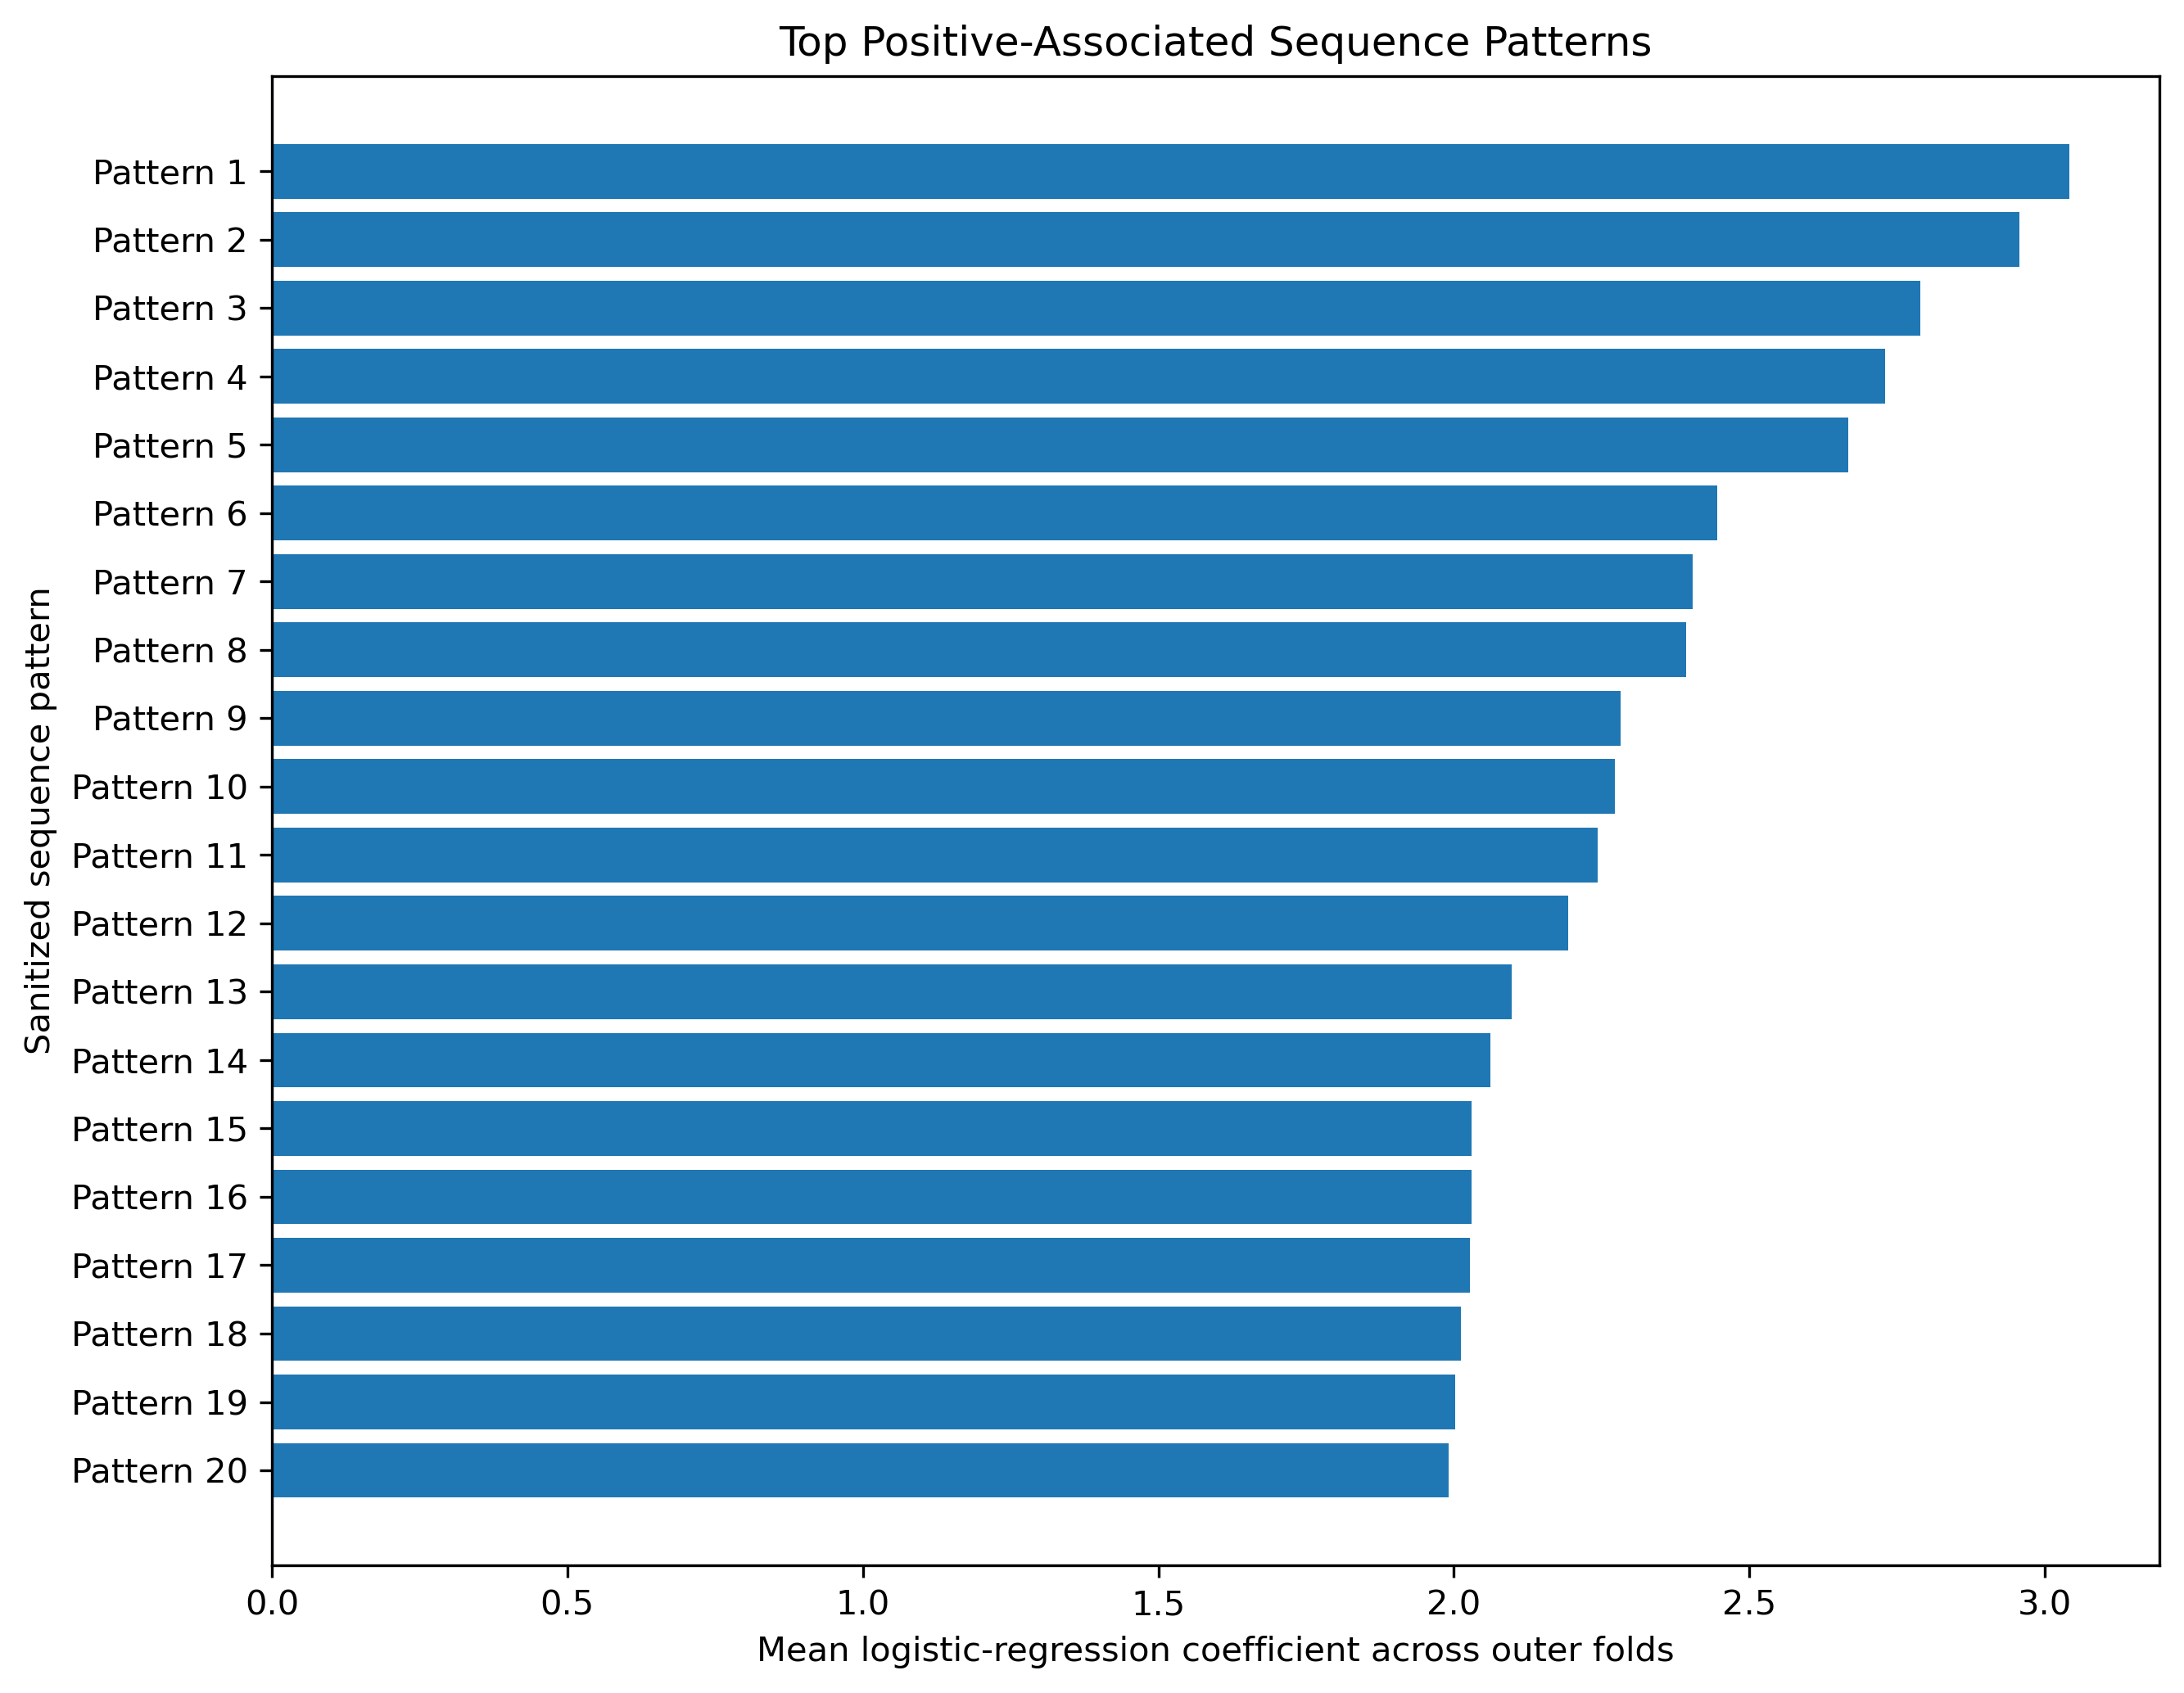

Top negative-associated sequence patterns


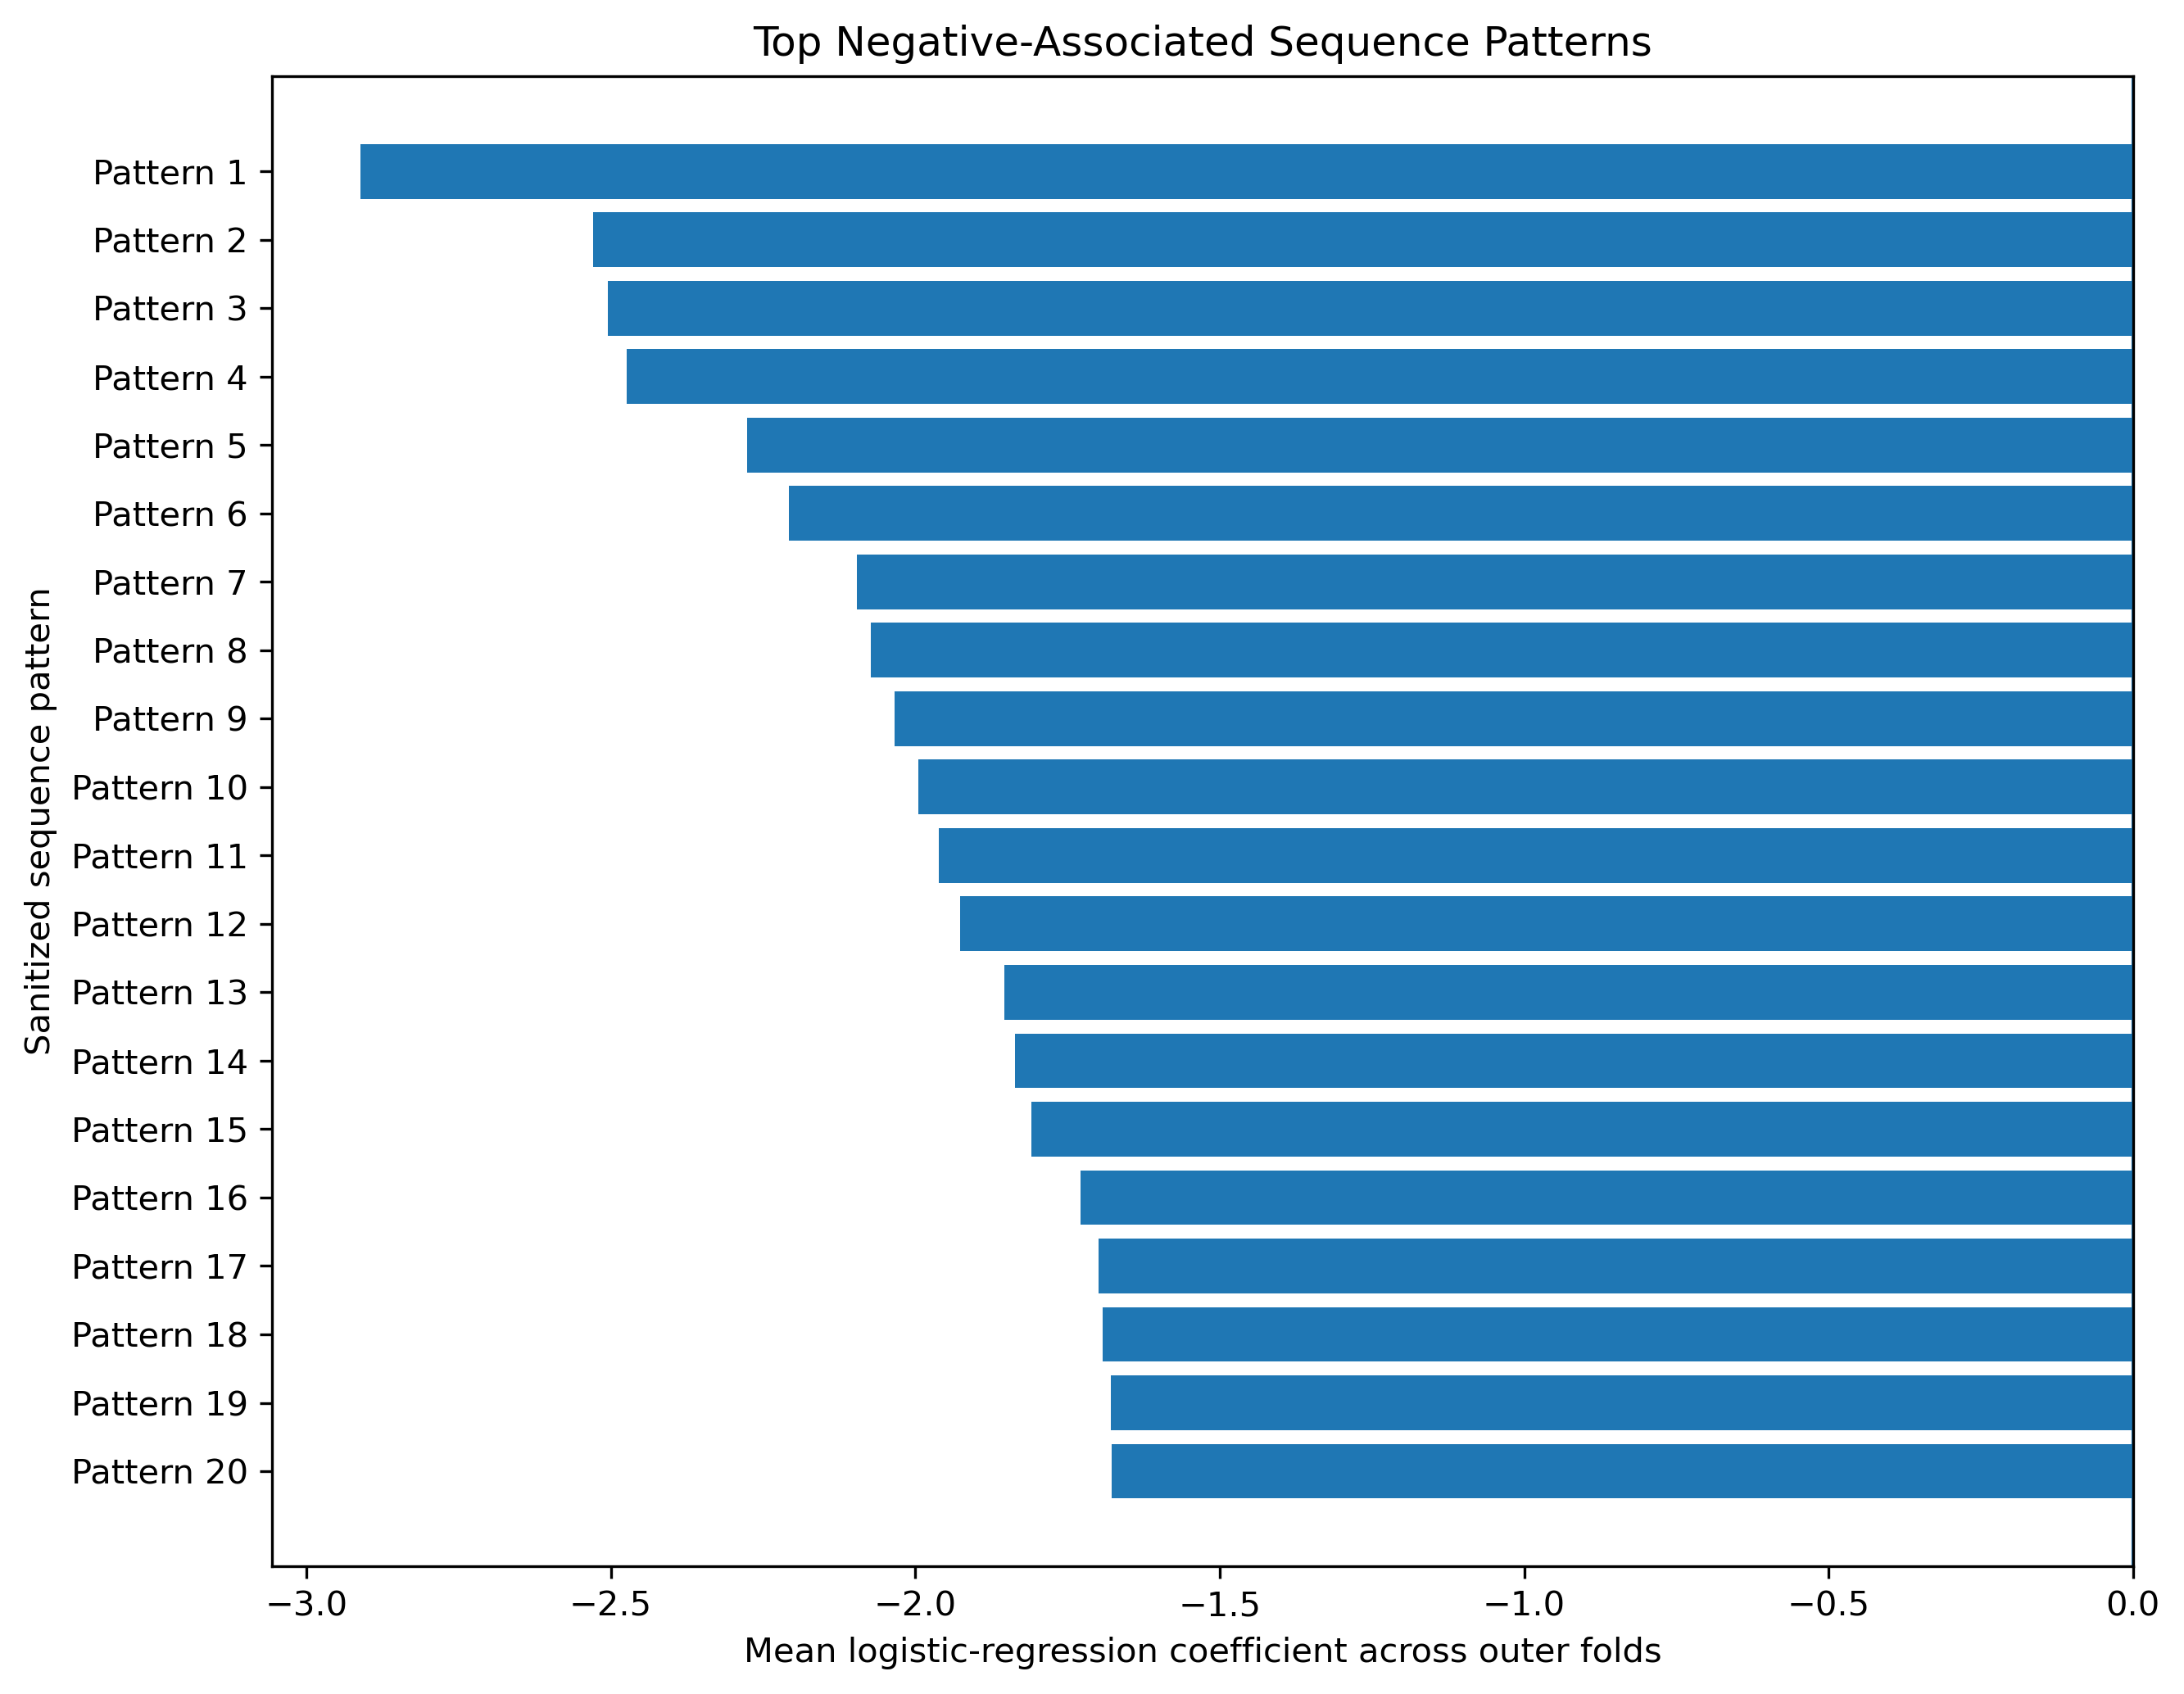

In [10]:
from IPython.display import display, Image

positive_figure = (
    RESULTS
    / "figures"
    / "kmer_interpretation"
    / "k5_top_positive_patterns_sanitized.png"
)

negative_figure = (
    RESULTS
    / "figures"
    / "kmer_interpretation"
    / "k5_top_negative_patterns_sanitized.png"
)

print("Top positive-associated sequence patterns")
display(Image(filename=str(positive_figure), width=750))

print("Top negative-associated sequence patterns")
display(Image(filename=str(negative_figure), width=750))

In [11]:
perturbation_public_path = (
    RESULTS
    / "metrics"
    / "in_silico_perturbation_public_summary.json"
)

with open(perturbation_public_path, "r", encoding="utf-8") as f:
    perturbation_public = json.load(f)

perturbation_df = pd.DataFrame(
    perturbation_public["aggregate_results"]
)

labels = {
    "insert_supported_positive": (
        "Insertion — supported positive"
    ),
    "insert_negative_control": (
        "Insertion — negative control"
    ),
    "insert_candidate_positive": (
        "Insertion — candidate positive"
    ),
    "disrupt_supported_positive": (
        "Disruption — supported positive"
    ),
    "disrupt_candidate_positive": (
        "Disruption — candidate positive"
    ),
}

perturbation_df["Perturbation"] = (
    perturbation_df["experiment"]
    .map(labels)
)

perturbation_summary_df = perturbation_df[
    [
        "Perturbation",
        "n",
        "mean_delta_probability",
        "fraction_probability_increased",
        "fraction_probability_decreased",
    ]
].rename(
    columns={
        "n": "n",
        "mean_delta_probability": "Mean Δ probability",
        "fraction_probability_increased": "Fraction increased",
        "fraction_probability_decreased": "Fraction decreased",
    }
)

print("In silico perturbation proof of concept")
display(perturbation_summary_df.round(3))

In silico perturbation proof of concept


,Perturbation,n,Mean Δ probability,Fraction increased,Fraction decreased
0,Insertion — supported positive,200,0.007,0.945,0.055
1,Insertion — negative control,200,-0.004,0.115,0.885
2,Insertion — candidate positive,200,0.002,0.675,0.325
3,Disruption — supported positive,139,-0.005,0.000,1.000
4,Disruption — candidate positive,160,-0.003,0.000,1.000


### In Silico Perturbation

As a final proof-of-concept analysis, the response of the frozen k-mer model to controlled sequence perturbations was evaluated on the independent test set.

Insertion of a sequence pattern associated with positive predictions increased the predicted probability in 94.5% of the evaluated promoters, whereas insertion of a negative-control pattern predominantly produced the opposite effect, decreasing the predicted probability in 88.5% of cases.

Perturbation of an additional positive candidate pattern produced a more moderate response but retained the expected direction in 67.5% of promoters. Complementarily, disruption of naturally occurring positive-associated patterns decreased the predicted probability in all evaluated cases.

The absolute magnitude of these changes was small. These results should therefore be interpreted as a proof of concept demonstrating **internal model sensitivity to controlled sequence modifications**, rather than evidence of biological causality or a promoter-design strategy.

The identities of the evaluated patterns and the independent regulatory resources used for their prioritization are not distributed due to confidentiality restrictions.

Efecto de las perturbaciones in silico sobre la probabilidad predicha


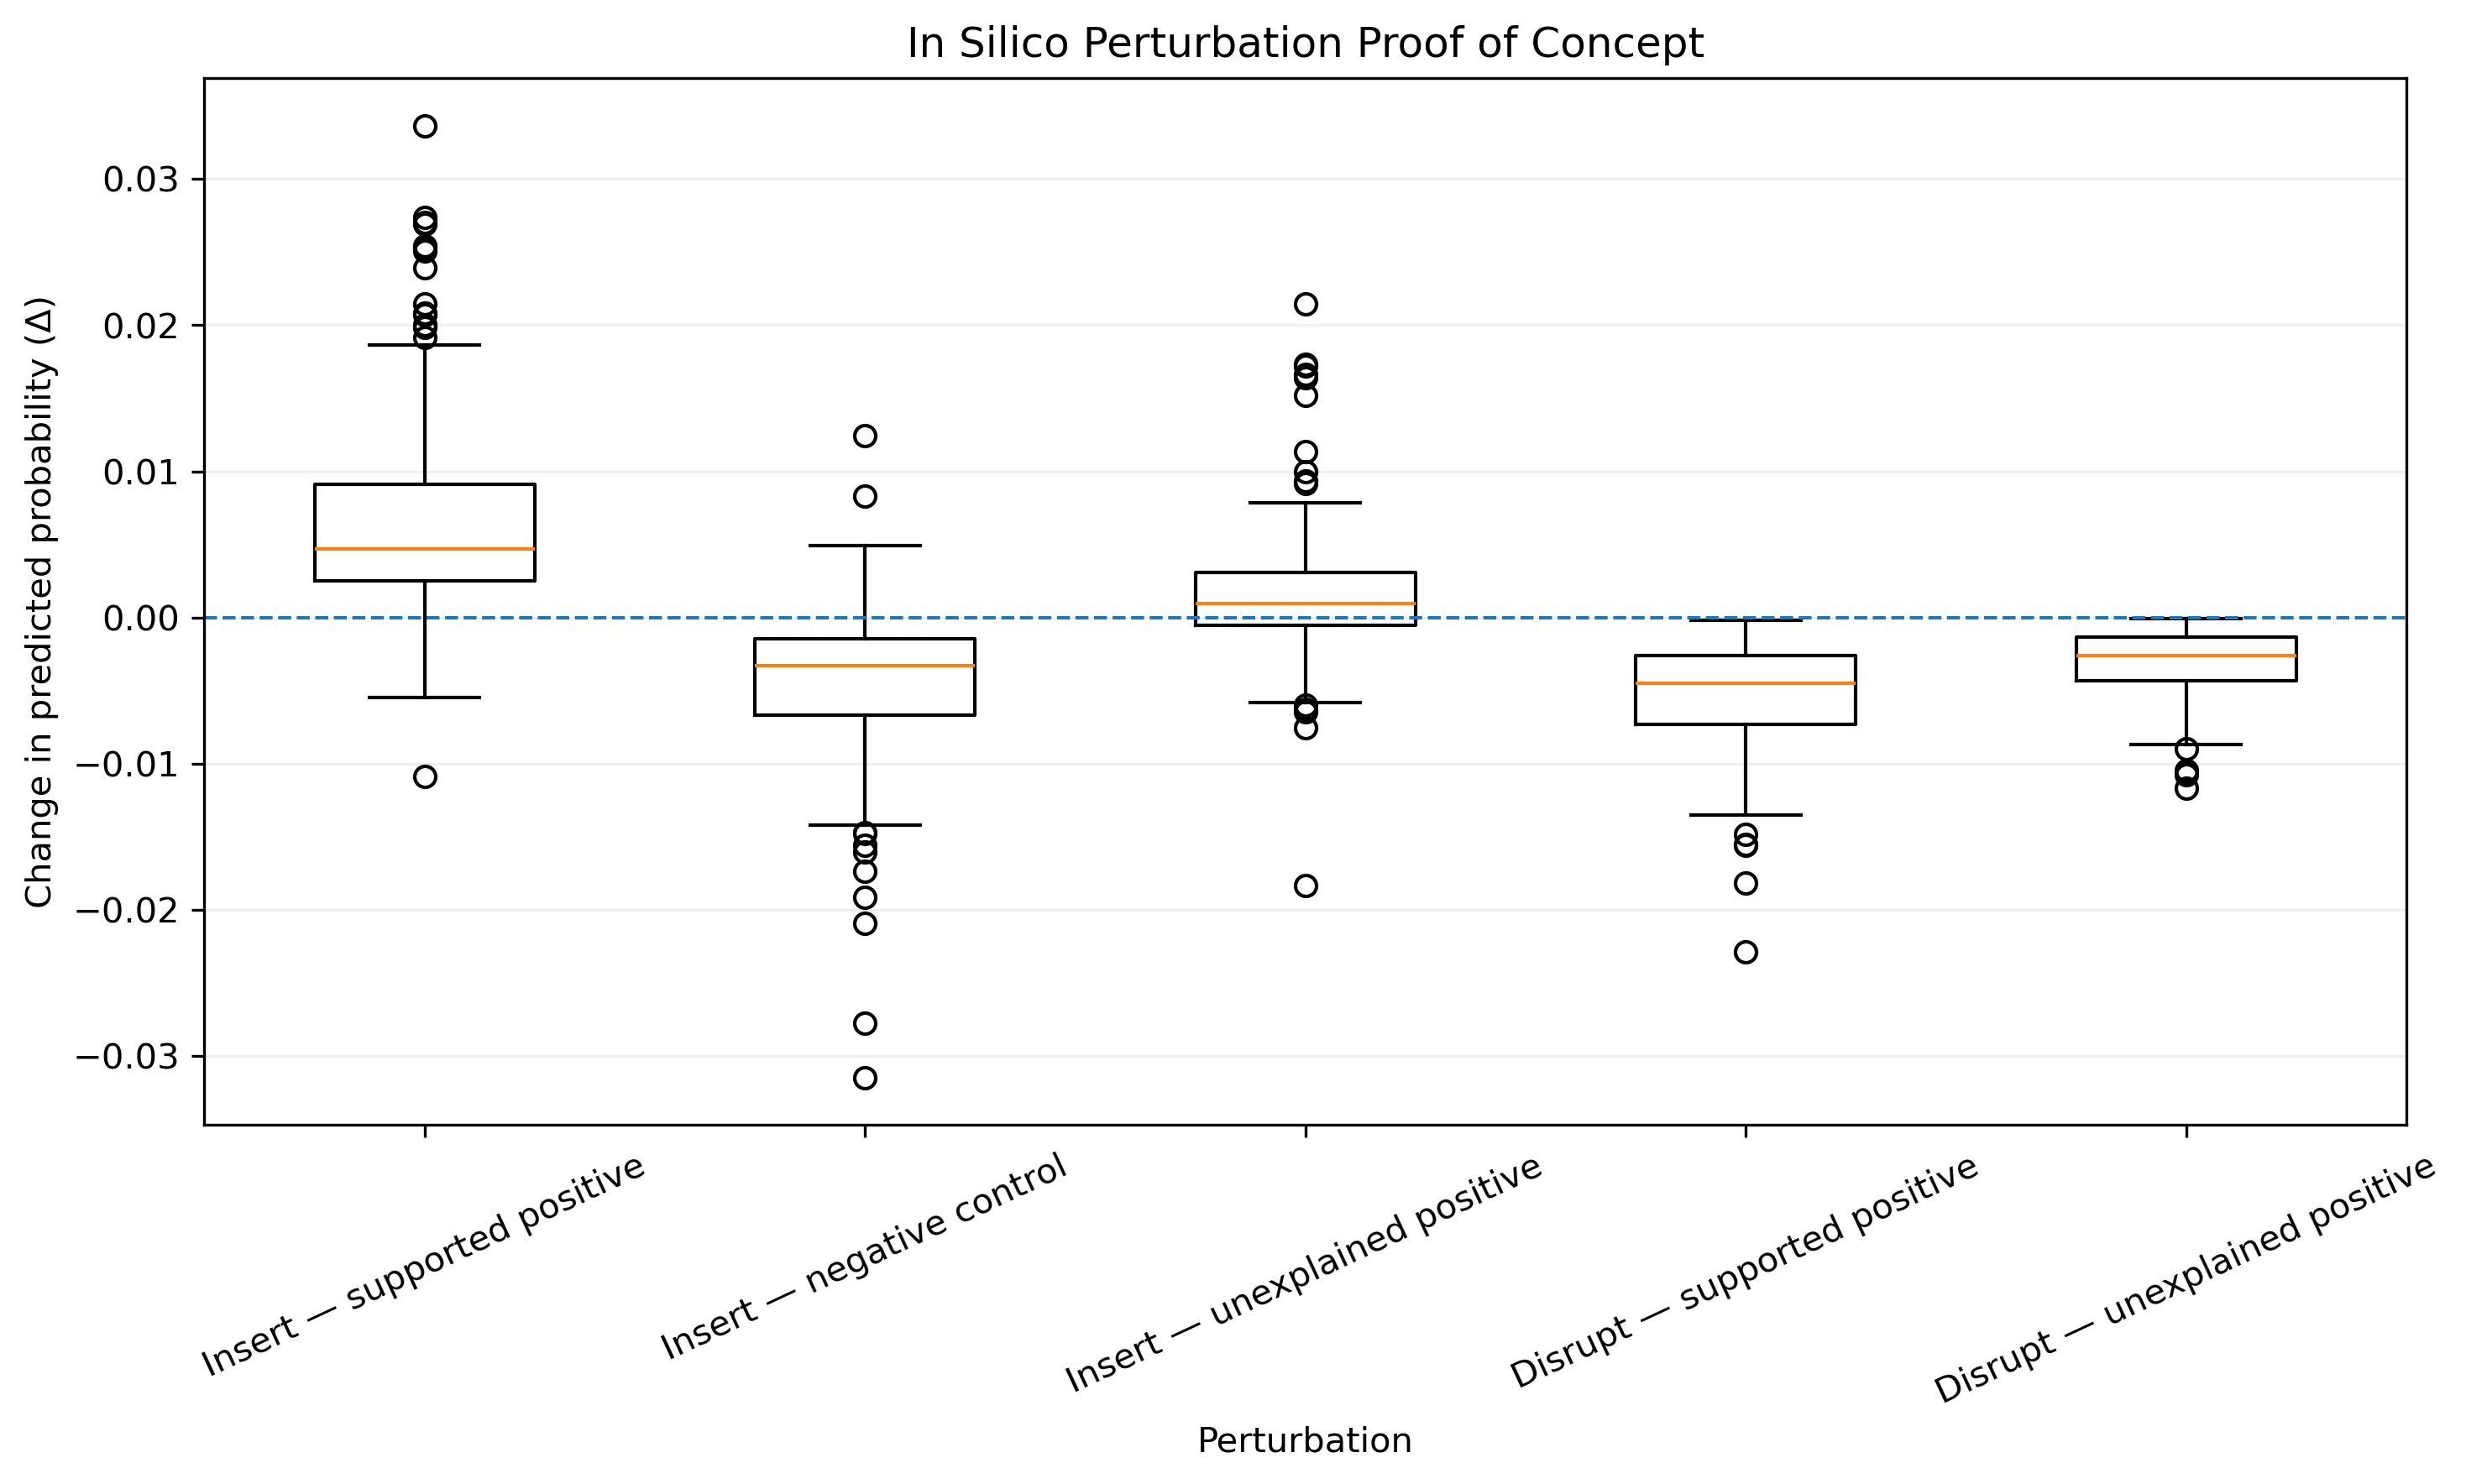

In [12]:
from IPython.display import Image, display

perturbation_figure = (
    RESULTS
    / "figures"
    / "in_silico_perturbation_delta_scores.png"
)

print("Efecto de las perturbaciones in silico sobre la probabilidad predicha")
display(Image(filename=str(perturbation_figure), width=950))

## Conclusions and Limitations

The analysis showed that promoter sequences contain a detectable predictive signal, although its magnitude was moderate and strongly dependent on the modeling strategy.

The CNN achieved above-random performance during development but did not generalize to the independent test set (AUPRC = 0.093 versus a positive-class prevalence of 0.090; AUROC = 0.465). In this dataset, increasing model complexity therefore did not translate into improved generalization.

In contrast, logistic regression based on k-mer frequencies showed a more consistent predictive signal. Nested cross-validation produced a mean AUPRC of 0.194 ± 0.043 and a mean AUROC of 0.651 ± 0.041. A subsequent permutation test performed with a fixed model configuration showed that the observed performance was above the null distribution (observed AUPRC = 0.197; empirical *p* = 0.005).

In the single evaluation on the independent test set, the frozen 5-mer model achieved an AUPRC of 0.184 and an AUROC of 0.612, compared with an expected random AUPRC of 0.090. However, the fixed classification threshold of 0.5 produced no positive predictions, demonstrating that ranking ability does not necessarily imply adequate calibration for binary classification at a given threshold.

Coefficient analysis identified sequence patterns with stable predictive associations across data partitions. In silico perturbation further produced directional responses consistent with these associations, although the absolute changes were small. These findings should be interpreted as evidence about the internal behavior of the predictive model rather than demonstration of regulatory causality.

Key limitations include the small number of positive examples, substantial class imbalance, limited availability of independent biological data, and confidentiality restrictions preventing distribution of parts of the original dataset and external regulatory resources.

Overall, the results favor a **simple and interpretable model over a more complex neural architecture in this specific data regime** and illustrate the importance of independent evaluation, permutation controls, leakage-aware dataset design, and explicit model interpretation when working with small and imbalanced biological datasets.